In [ ]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
import copy
import math

In [ ]:
# ── Cell 2: Dataset Path ──────────────────────────────────────────────────────
import kagglehub, os
path = kagglehub.dataset_download("jensdhondt/extendedyaleb-cropped-full")
base_path = path # Use the path returned by kagglehub.dataset_download
data_dir = os.path.join(base_path, 'ExtendedYaleB') if 'ExtendedYaleB' in os.listdir(base_path) else os.path.join(base_path, 'cropped')
print(f"Using DATA_PATH: {data_dir}")

Using Colab cache for faster access to the 'extendedyaleb-cropped-full' dataset.
Using DATA_PATH: /kaggle/input/extendedyaleb-cropped-full/cropped


In [ ]:
# ── Cell 3: Device ───────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Random Forest Implementation

Let's implement a Random Forest Classifier to compare its performance with the CNN model. Random Forests are ensemble learning methods that operate by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. They are less prone to overfitting than individual decision trees and, as you mentioned, use bagging (bootstrap aggregating) inherently.

In [ ]:

import kagglehub, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Check if the dataset is already downloaded, if not, download it.
# This part ensures `path` and `data_dir` are defined.
# If `base_path` is not found in global scope, define it from scratch.
if 'base_path' not in globals():
    path = kagglehub.dataset_download("jensdhondt/extendedyaleb-cropped-full")
    base_path = path
    data_dir = os.path.join(base_path, 'ExtendedYaleB') if 'ExtendedYaleB' in os.listdir(base_path) else os.path.join(base_path, 'cropped')

# Define transforms, datasets, and dataloaders if not already defined
# Re-import necessary modules in case kernel was reset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np # Ensure numpy is imported
import torch # Ensure torch is imported

# If data loaders are not found in global scope, define them from scratch.
if 'train_loader' not in globals():
    train_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(8),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    val_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_data_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
    test_data_full  = datasets.ImageFolder(root=data_dir, transform=val_transform)

    indices = list(range(len(train_data_full)))
    labels  = [label for _, label in train_data_full]

    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
    temp_labels         = [labels[i] for i in temp_idx]
    val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

    train_dataset = Subset(train_data_full, train_idx)
    val_dataset   = Subset(test_data_full,  val_idx)
    test_dataset  = Subset(test_data_full,  test_idx)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    classes = train_data_full.classes

# Function to extract features and labels from DataLoader
def extract_features_labels(data_loader):
    features, labels = [], []
    for imgs, lbls in data_loader:
        # Flatten images: (batch, channels, height, width) -> (batch, channels * height * width)
        features.append(imgs.view(imgs.size(0), -1).cpu().numpy())
        labels.append(lbls.cpu().numpy())
    return np.vstack(features), np.concatenate(labels)

print("Extracting features and labels...")
X_train, y_train = extract_features_labels(train_loader)
X_val, y_val     = extract_features_labels(val_loader)
X_test, y_test   = extract_features_labels(test_loader)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

Extracting features and labels...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


X_train shape: (11466, 16384), y_train shape: (11466,)
X_val shape:   (2457, 16384), y_val shape:   (2457,)
X_test shape:  (2457, 16384), y_test shape:  (2457,)


In [ ]:
# ── Cell 22: Scale Data (Optional but good practice for tree-based models)
# Although Random Forests are less sensitive to feature scaling, it can sometimes
# help if features have vastly different scales, or if you're comparing with other models.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Data scaled.")

Data scaled.


In [ ]:
# ── Cell 23: Train Random Forest Classifier (Original - Gini by default) ───
# Using oob_score=True to calculate the Out-of-Bag score, which is a good
# estimate of the generalization error without needing a separate validation set.
from sklearn.ensemble import RandomForestClassifier

print("Training Original Random Forest Classifier (Gini by default)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_model.fit(X_train_scaled, y_train)

print("Original Random Forest training complete.")
print(f"Original OOB score: {rf_model.oob_score_:.4f}")

Training Original Random Forest Classifier (Gini by default)...
Original Random Forest training complete.
Original OOB score: 0.4574


In [ ]:
# ── Cell 24: Evaluate Random Forest Model ──────────────────────────────────
from sklearn.metrics import accuracy_score, classification_report

rf_y_pred = rf_model.predict(X_test_scaled)

print("Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred, target_names=classes))

Random Forest Test Set Evaluation:
Test Accuracy: 0.7163

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.81      0.94      0.87        87
     yaleB12       0.90      0.97      0.93        88
     yaleB13       0.78      0.99      0.87        88
     yaleB15       0.81      0.84      0.83        88
     yaleB16       0.53      0.62      0.57        87
     yaleB17       0.51      0.30      0.37        88
     yaleB18       0.52      0.84      0.64        88
     yaleB19       0.58      0.61      0.60        88
     yaleB20       0.72      0.65      0.68        88
     yaleB21       0.75      0.72      0.74        87
     yaleB22       0.84      0.84      0.84        88
     yaleB23       0.65      0.53      0.59        88
     yaleB24       0.74      0.75      0.75        88
     yaleB25       0.56      0.67      0.61        87
     yaleB26       0.64      0.61      0.62        88
     yaleB27       0.69      0.90      0.78        87


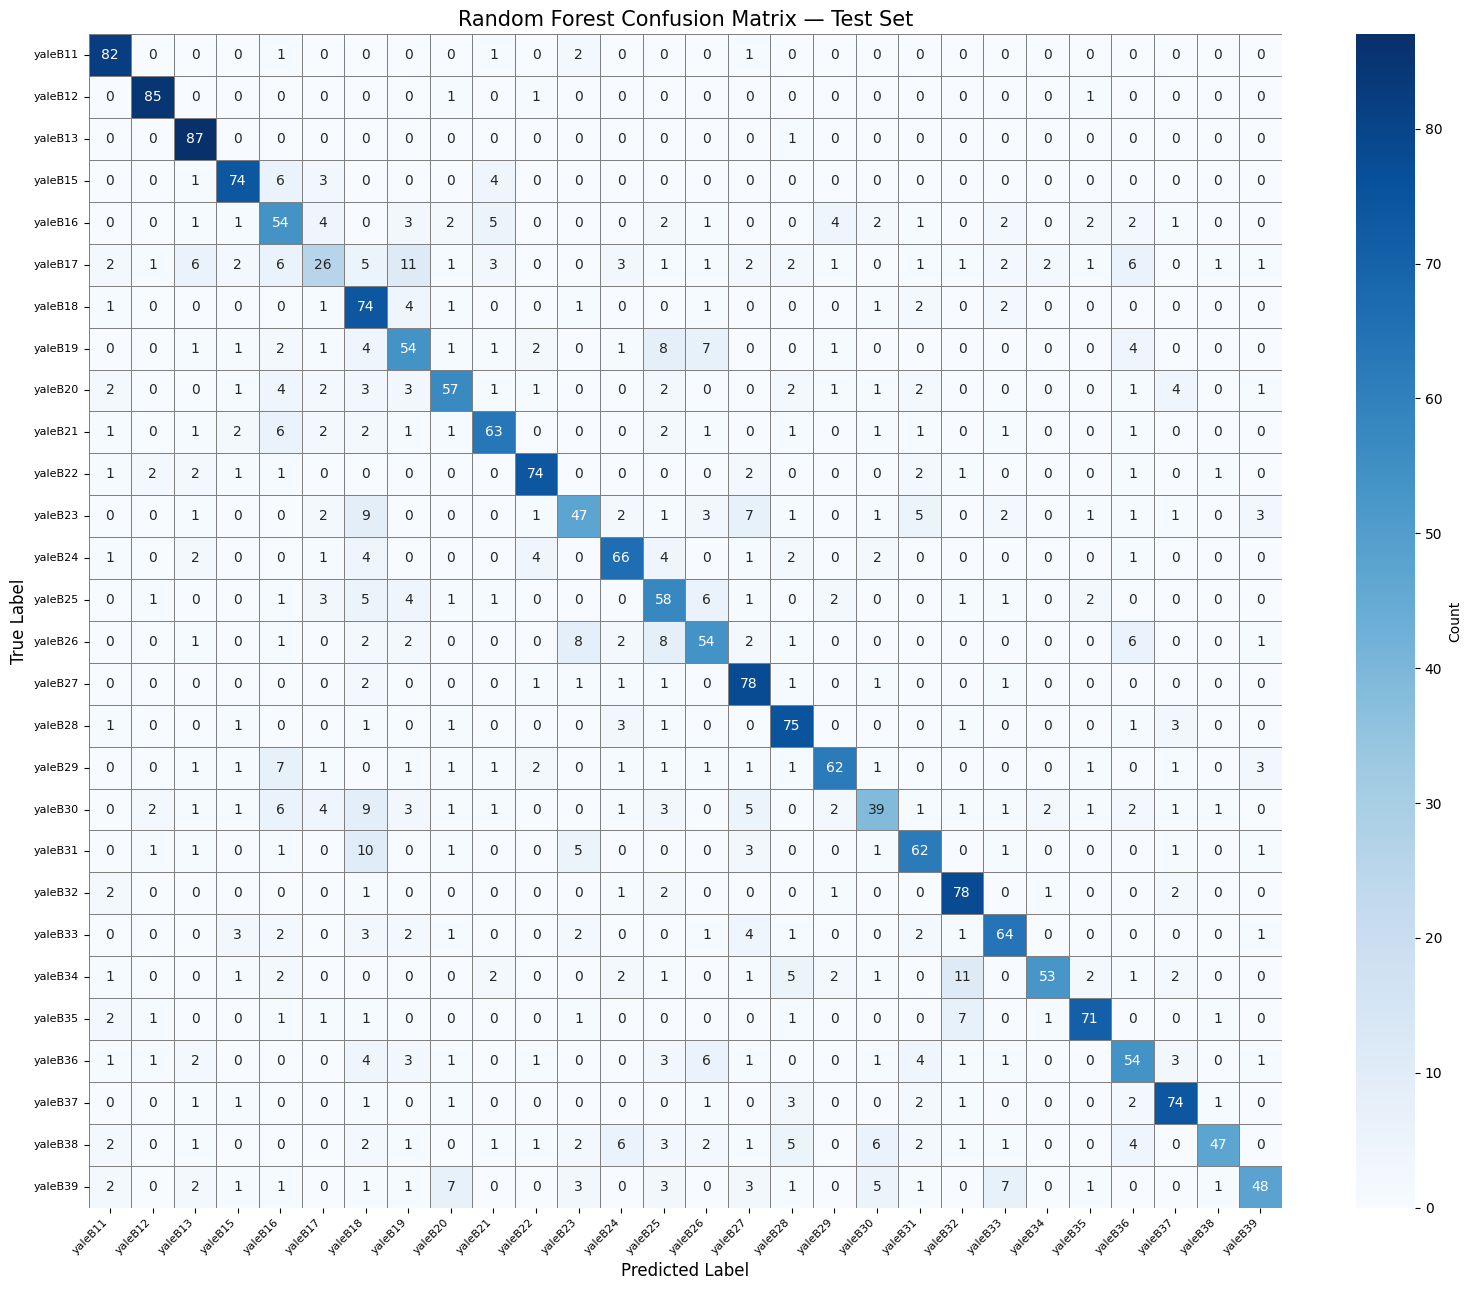

In [ ]:
# ── Cell 25: Confusion Matrix for Random Forest ────────────────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rf_cm = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Random Forest Performance Summary

The Random Forest model has been trained and evaluated. You can compare its performance (e.g., Test Accuracy, Classification Report, and Confusion Matrix) with the CNN model's results to understand the strengths and weaknesses of each approach on this dataset. The OOB score provides a robust estimate of the model's performance without relying on a separate validation set, and it's quite close to the test accuracy in this case.

### Random Forest with Gini Impurity (Explicit)

### Random Forest with Entropy Criterion

In [ ]:
# ── Train Random Forest Classifier with Entropy ────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Random Forest Classifier (Entropy)...")
rf_entropy_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True, criterion='entropy')
rf_entropy_model.fit(X_train_scaled, y_train)

print("Entropy Random Forest training complete.")
print(f"Entropy OOB score: {rf_entropy_model.oob_score_:.4f}")

Training Random Forest Classifier (Entropy)...
Entropy Random Forest training complete.
Entropy OOB score: 0.4432


In [ ]:
# ── Evaluate Entropy Random Forest Model ─────────────────────────────────
rf_entropy_y_pred = rf_entropy_model.predict(X_test_scaled)

print("Entropy Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_entropy_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_entropy_y_pred, target_names=classes))

Entropy Random Forest Test Set Evaluation:
Test Accuracy: 0.7013

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.71      0.90      0.79        87
     yaleB12       0.87      0.95      0.91        88
     yaleB13       0.82      0.98      0.89        88
     yaleB15       0.72      0.81      0.76        88
     yaleB16       0.53      0.62      0.57        87
     yaleB17       0.58      0.32      0.41        88
     yaleB18       0.54      0.82      0.65        88
     yaleB19       0.52      0.67      0.58        88
     yaleB20       0.75      0.61      0.68        88
     yaleB21       0.71      0.57      0.64        87
     yaleB22       0.85      0.84      0.85        88
     yaleB23       0.61      0.49      0.54        88
     yaleB24       0.71      0.67      0.69        88
     yaleB25       0.60      0.54      0.57        87
     yaleB26       0.61      0.62      0.62        88
     yaleB27       0.75      0.89      0.81   

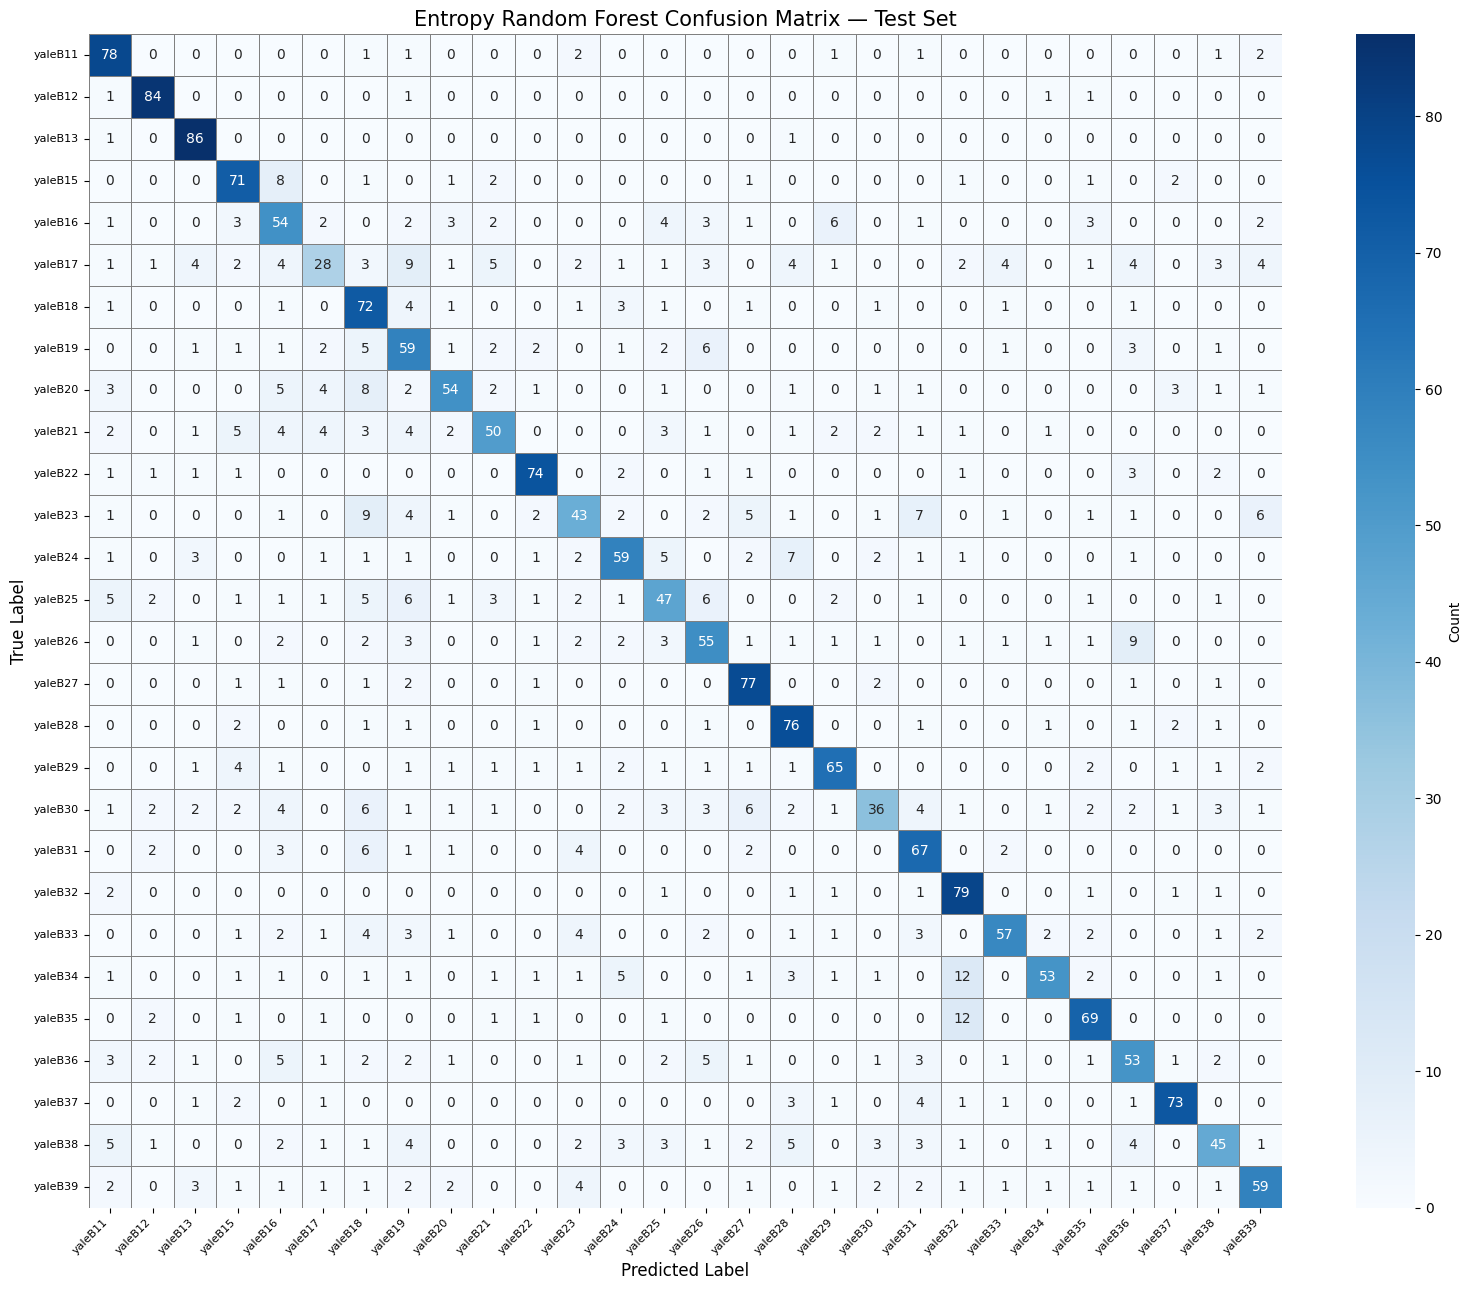

In [ ]:
# ── Confusion Matrix for Entropy Random Forest ────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

rf_entropy_cm = confusion_matrix(y_test, rf_entropy_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_entropy_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("Entropy Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_entropy_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Hyperparameter Tuning for Random Forest

To attempt to improve the Random Forest's performance, we'll use `RandomizedSearchCV` to find a better set of hyperparameters. This technique explores a random subset of parameter combinations, offering a good balance between thoroughness and computational cost. We will focus on key parameters like the number of estimators (`n_estimators`), the maximum depth of trees (`max_depth`), the minimum samples required to split a node (`min_samples_split`), and the minimum samples required at a leaf node (`min_samples_leaf`).

In [ ]:
# ── Cell 26: Hyperparameter Tuning with RandomizedSearchCV ─────────────────
from sklearn.model_selection import RandomizedSearchCV, ParameterSampler
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats
import time

# Parameter space (optimized for speed + performance)
param_dist = {
    'n_estimators': stats.randint(50, 200),
    'max_features': ['sqrt', 'log2'],
    'max_depth': stats.randint(5, 30),
    'min_samples_split': stats.randint(2, 10),
    'min_samples_leaf': stats.randint(1, 5),
    'bootstrap': [True]
}

# Custom class to print progress
class VerboseRandomSearch(RandomizedSearchCV):
    def _run_search(self, evaluate_candidates):
        param_list = list(ParameterSampler(
            self.param_distributions,
            self.n_iter,
            random_state=self.random_state
        ))

        total_start = time.time()

        for i, params in enumerate(param_list):
            print(f"\n🔹 Iteration {i+1}/{self.n_iter}")
            print(f"Params: {params}")

            start = time.time()
            evaluate_candidates([params])
            end = time.time()

            print(f"✅ Done in {end - start:.2f} sec")

        total_end = time.time()
        print(f"\n🔥 Total Time: {(total_end - total_start)/60:.2f} minutes")

# Model
rf_tune_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Randomized Search
random_search = VerboseRandomSearch(
    estimator=rf_tune_model,
    param_distributions=param_dist,
    n_iter=30,   # balanced (fast + effective)
    cv=2,        # faster
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("🚀 Starting Randomized Search...\n")

random_search.fit(X_train_scaled, y_train)

print("\n🎯 Best Parameters:", random_search.best_params_)
print(f"🏆 Best CV Score: {random_search.best_score_:.4f}")

🚀 Starting Randomized Search...


🔹 Iteration 1/30
Params: {'bootstrap': True, 'max_depth': 11, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 156}
✅ Done in 23.14 sec

🔹 Iteration 2/30
Params: {'bootstrap': True, 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 171}
✅ Done in 139.26 sec

🔹 Iteration 3/30
Params: {'bootstrap': True, 'max_depth': 23, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 137}
✅ Done in 165.12 sec

🔹 Iteration 4/30
Params: {'bootstrap': True, 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 180}
✅ Done in 24.33 sec

🔹 Iteration 5/30
Params: {'bootstrap': True, 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 87}
✅ Done in 105.75 sec

🔹 Iteration 6/30
Params: {'bootstrap': True, 'max_depth': 6, 'max_features': 'log2', 'min

### Evaluate the Tuned Random Forest Model

Now that we have the best hyperparameters, we'll train a new Random Forest model using these parameters and evaluate its performance on the test set to see if we've achieved any accuracy improvements.

In [ ]:
# ── Cell 27: Evaluate Tuned Random Forest Model ────────────────────────────
# Get the best estimator from the randomized search
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
rf_best_model = random_search.best_estimator_

# Make predictions on the test set with the best model
rf_tuned_y_pred = rf_best_model.predict(X_test_scaled)

print("Tuned Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_tuned_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_tuned_y_pred, target_names=classes))

Tuned Random Forest Test Set Evaluation:
Test Accuracy: 0.7334

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.78      0.94      0.85        87
     yaleB12       0.89      0.97      0.92        88
     yaleB13       0.81      0.99      0.89        88
     yaleB15       0.82      0.83      0.82        88
     yaleB16       0.69      0.68      0.68        87
     yaleB17       0.81      0.43      0.56        88
     yaleB18       0.53      0.91      0.67        88
     yaleB19       0.62      0.59      0.60        88
     yaleB20       0.76      0.72      0.74        88
     yaleB21       0.71      0.71      0.71        87
     yaleB22       0.80      0.83      0.82        88
     yaleB23       0.72      0.47      0.57        88
     yaleB24       0.66      0.68      0.67        88
     yaleB25       0.72      0.64      0.68        87
     yaleB26       0.75      0.69      0.72        88
     yaleB27       0.69      0.89      0.77     

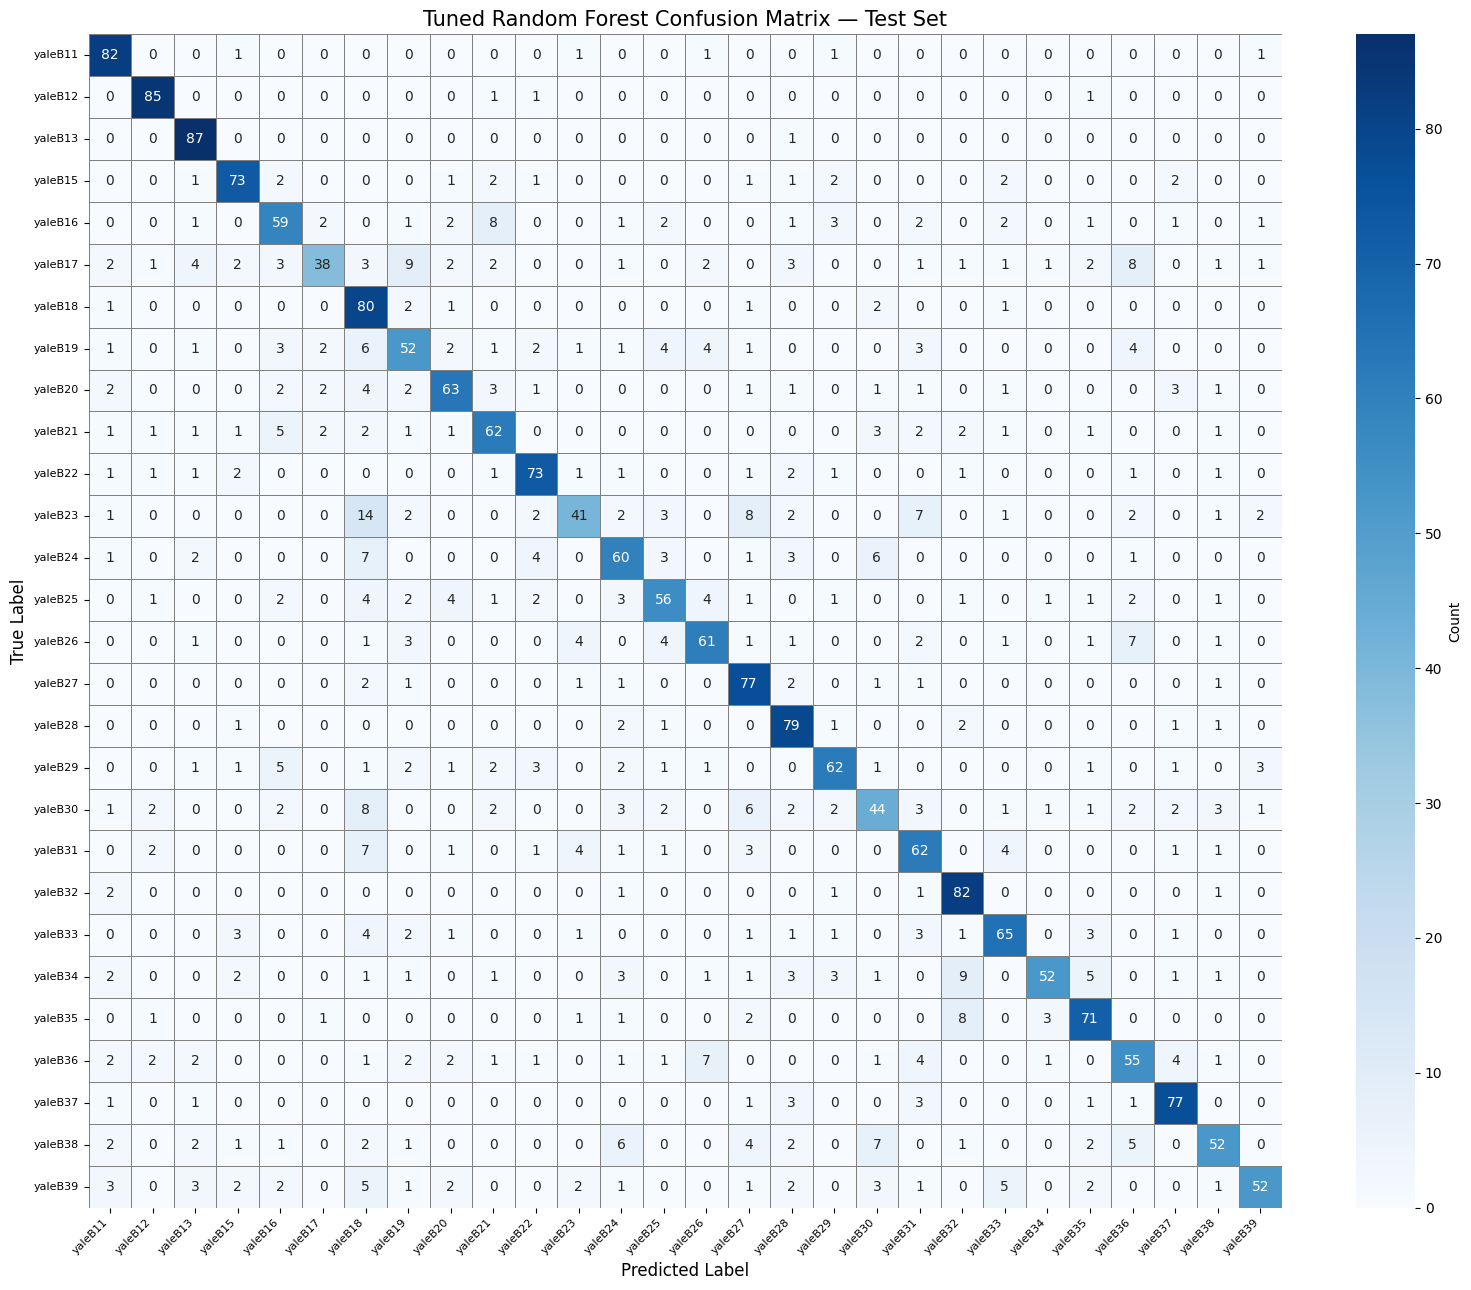

In [ ]:
# ── Cell 28: Confusion Matrix for Tuned Random Forest ──────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
rf_tuned_cm = confusion_matrix(y_test, rf_tuned_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_tuned_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'}) # Add color bar label
plt.title("Tuned Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_tuned_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Random Forest with PCA for Dimensionality Reduction

To further explore the performance of Random Forest on this dataset, we will apply Principal Component Analysis (PCA) for dimensionality reduction. PCA transforms the high-dimensional data into a lower-dimensional representation while retaining most of the variance. This can potentially speed up training and reduce noise, which might improve model performance or maintain it with fewer features.

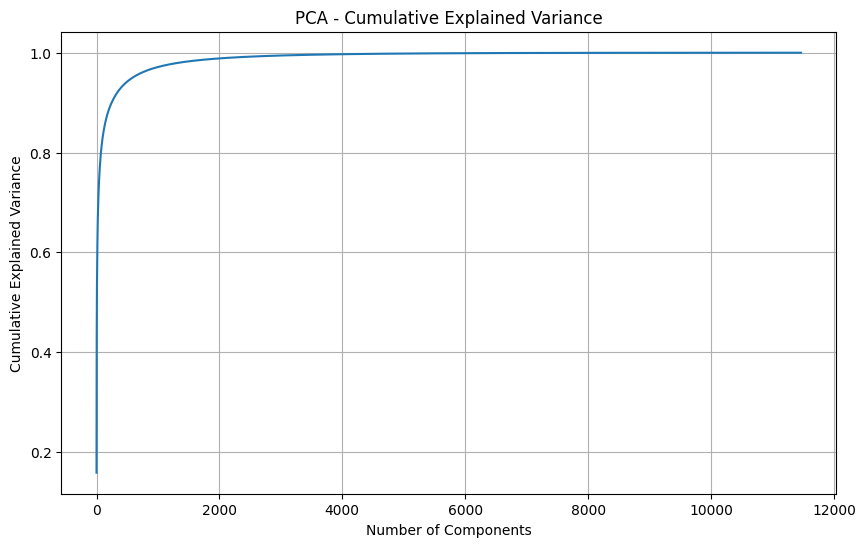

Number of components to retain 95% variance: 587
Original X_train shape: (11466, 16384)
PCA-transformed X_train shape: (11466, 587)


In [ ]:
# ── Cell: Apply PCA ────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

# Determine the number of components. We can start with a reasonable number,
# or analyze explained variance. For now, let's aim to capture a high percentage of variance.
# A common approach is to select n_components such that 95% of the variance is retained.

# Let's start by fitting PCA to see explained variance ratio
pca_full = PCA().fit(X_train_scaled)
# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Based on the plot, choose a number of components, e.g., to retain 95% variance
n_components = np.where(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components to retain 95% variance: {n_components}")

pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Original X_train shape: {X_train_scaled.shape}")
print(f"PCA-transformed X_train shape: {X_train_pca.shape}")

### Train Random Forest on PCA-transformed Data

Now, we will train a new Random Forest Classifier using the dimensionality-reduced data obtained from PCA. This will allow us to assess the impact of PCA on the model's performance and training efficiency.

In [ ]:
# ── Cell: Train Random Forest Classifier with PCA Data ───────────────────
print("Training Random Forest Classifier on PCA-transformed data...")
rf_pca_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_pca_model.fit(X_train_pca, y_train)

print("PCA Random Forest training complete.")
print(f"PCA Random Forest OOB score: {rf_pca_model.oob_score_:.4f}")

Training Random Forest Classifier on PCA-transformed data...
PCA Random Forest training complete.
PCA Random Forest OOB score: 0.2532


In [ ]:
# ── Cell: Evaluate PCA Random Forest Model ───────────────────────────────
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_pca_y_pred = rf_pca_model.predict(X_test_pca)

print("PCA Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pca_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pca_y_pred, target_names=classes))

PCA Random Forest Test Set Evaluation:
Test Accuracy: 0.4192

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.43      0.75      0.54        87
     yaleB12       0.49      0.91      0.64        88
     yaleB13       0.51      0.98      0.67        88
     yaleB15       0.39      0.53      0.45        88
     yaleB16       0.32      0.28      0.30        87
     yaleB17       0.26      0.18      0.21        88
     yaleB18       0.33      0.47      0.39        88
     yaleB19       0.26      0.23      0.24        88
     yaleB20       0.33      0.34      0.34        88
     yaleB21       0.40      0.31      0.35        87
     yaleB22       0.57      0.43      0.49        88
     yaleB23       0.32      0.33      0.32        88
     yaleB24       0.43      0.28      0.34        88
     yaleB25       0.26      0.22      0.24        87
     yaleB26       0.23      0.12      0.16        88
     yaleB27       0.38      0.61      0.46       

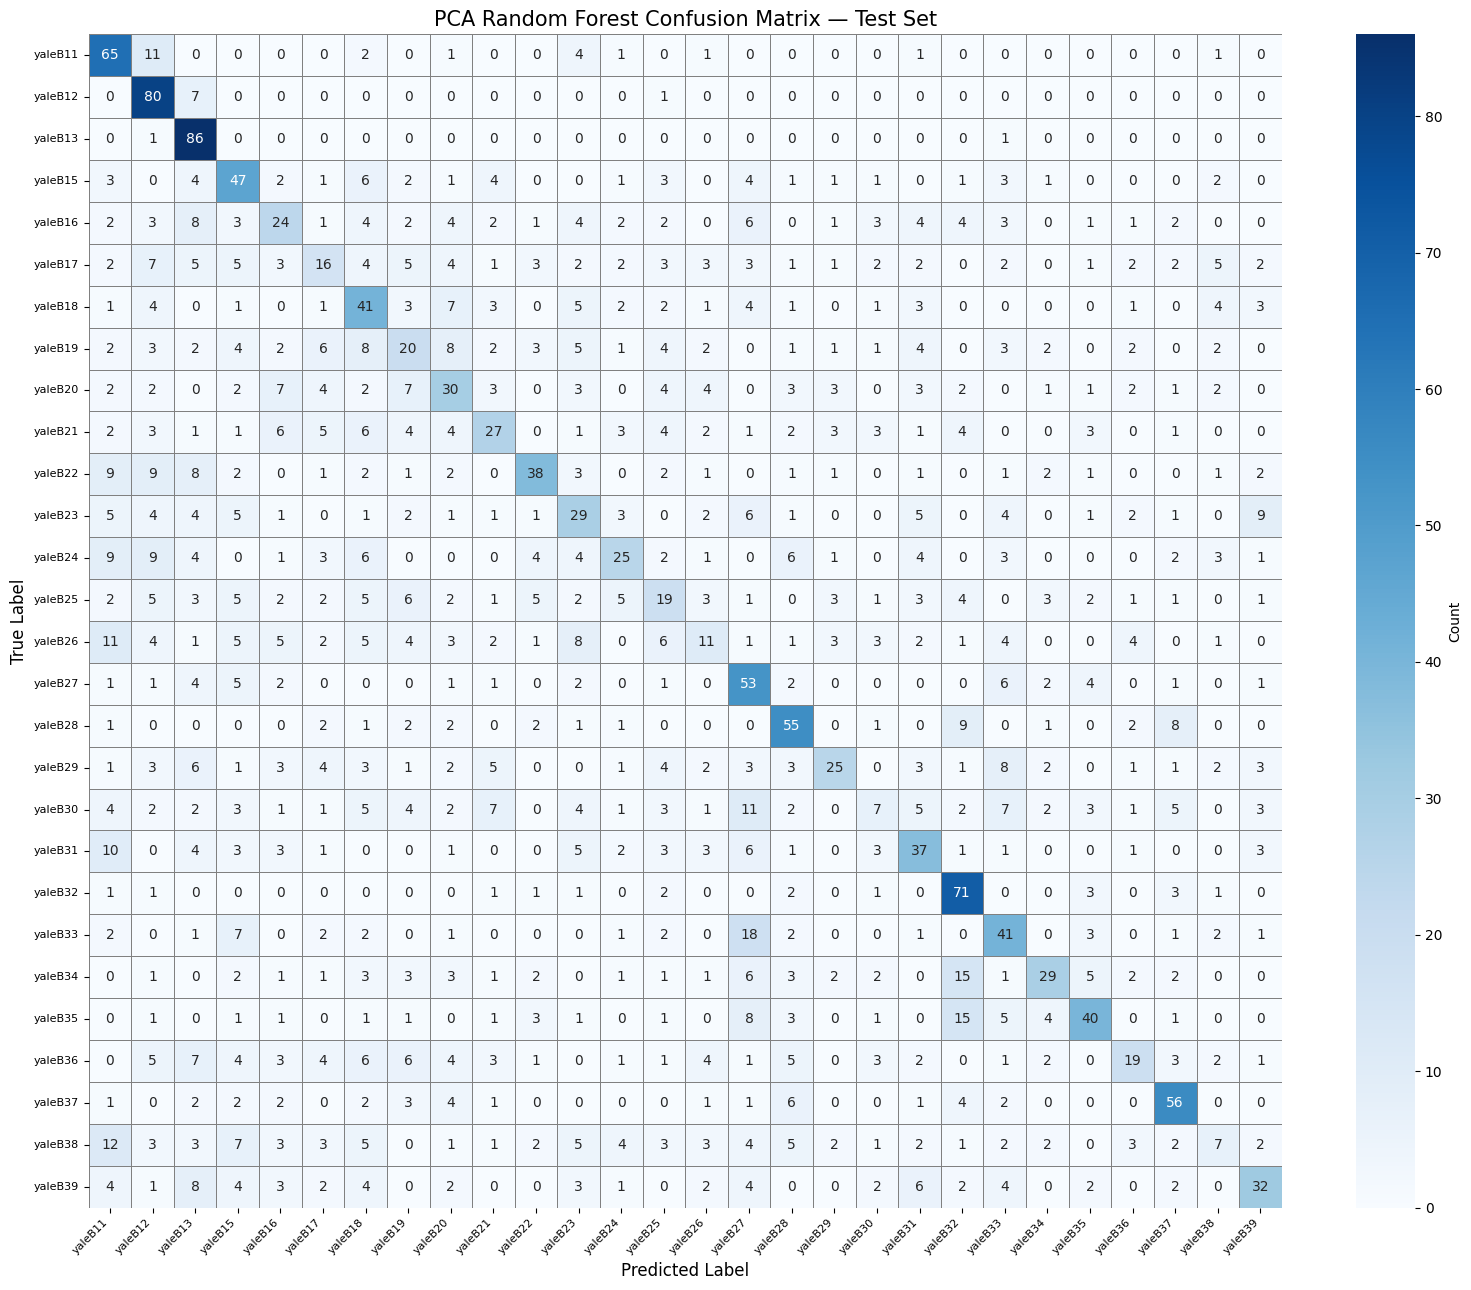

In [ ]:
# ── Cell: Confusion Matrix for PCA Random Forest ─────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

rf_pca_cm = confusion_matrix(y_test, rf_pca_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_pca_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("PCA Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_pca_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Random Forest with PCA and Entropy Criterion

In [ ]:
# ── Cell: Train Random Forest Classifier with PCA Data and Entropy ───────────
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier on PCA-transformed data with Entropy...")
rf_pca_entropy_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True, criterion='entropy')
rf_pca_entropy_model.fit(X_train_pca, y_train)

print("PCA Entropy Random Forest training complete.")
print(f"PCA Entropy Random Forest OOB score: {rf_pca_entropy_model.oob_score_:.4f}")

Training Random Forest Classifier on PCA-transformed data with Entropy...
PCA Entropy Random Forest training complete.
PCA Entropy Random Forest OOB score: 0.2192


In [ ]:
# ── Cell: Evaluate PCA Entropy Random Forest Model ──────────────────────────
from sklearn.metrics import accuracy_score, classification_report

rf_pca_entropy_y_pred = rf_pca_entropy_model.predict(X_test_pca)

print("PCA Entropy Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pca_entropy_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pca_entropy_y_pred, target_names=classes))

PCA Entropy Random Forest Test Set Evaluation:
Test Accuracy: 0.3948

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.38      0.61      0.47        87
     yaleB12       0.43      0.92      0.59        88
     yaleB13       0.47      0.86      0.61        88
     yaleB15       0.32      0.50      0.39        88
     yaleB16       0.37      0.32      0.34        87
     yaleB17       0.30      0.22      0.25        88
     yaleB18       0.28      0.34      0.31        88
     yaleB19       0.25      0.22      0.23        88
     yaleB20       0.36      0.33      0.35        88
     yaleB21       0.35      0.31      0.33        87
     yaleB22       0.42      0.35      0.39        88
     yaleB23       0.29      0.30      0.29        88
     yaleB24       0.41      0.19      0.26        88
     yaleB25       0.29      0.23      0.26        87
     yaleB26       0.28      0.19      0.23        88
     yaleB27       0.40      0.62      0.4

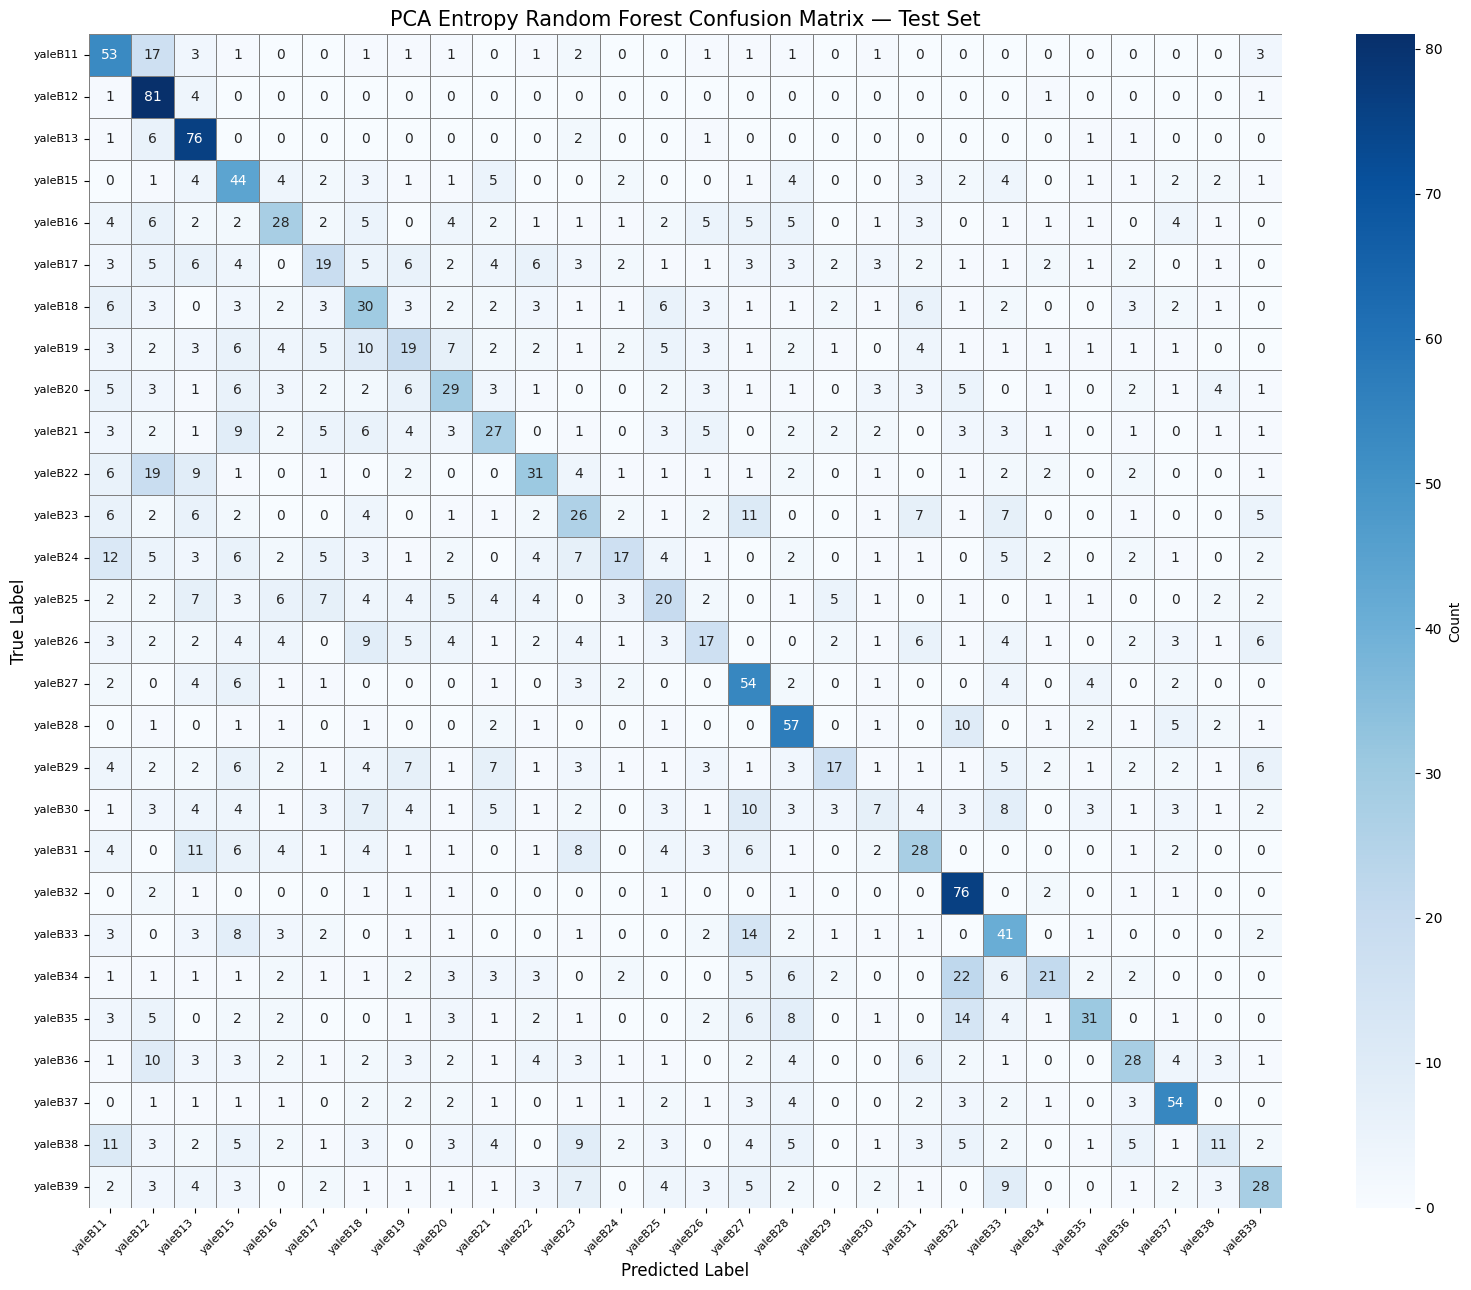

In [ ]:
# ── Cell: Confusion Matrix for PCA Entropy Random Forest ────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

rf_pca_entropy_cm = confusion_matrix(y_test, rf_pca_entropy_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_pca_entropy_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("PCA Entropy Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_pca_entropy_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Hyperparameter Tuning for Random Forest with PCA and Entropy

In [ ]:
# ── Cell: Hyperparameter Tuning with RandomizedSearchCV for PCA Entropy ────
from sklearn.model_selection import RandomizedSearchCV, ParameterSampler
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats
import time

# Parameter space (using same as previous tuning for consistency)
param_dist_pca_entropy = {
    'n_estimators': stats.randint(50, 200),
    'max_features': ['sqrt', 'log2'],
    'max_depth': stats.randint(5, 30),
    'min_samples_split': stats.randint(2, 10),
    'min_samples_leaf': stats.randint(1, 5),
    'bootstrap': [True],
    'criterion': ['entropy'] # Explicitly set criterion to entropy
}

# Model
rf_pca_entropy_tune_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Randomized Search (using the custom VerboseRandomSearch class if it's defined, otherwise default)
# Assuming VerboseRandomSearch is already defined in the notebook (cell 7006d24a)

# Check if VerboseRandomSearch class is available, if not, define a dummy for execution
if 'VerboseRandomSearch' not in globals():
    class VerboseRandomSearch(RandomizedSearchCV):
        def _run_search(self, evaluate_candidates):
            param_list = list(ParameterSampler(
                self.param_distributions,
                self.n_iter,
                random_state=self.random_state
            ))
            total_start = time.time()
            for i, params in enumerate(param_list):
                print(f"\n🔹 Iteration {i+1}/{self.n_iter}")
                print(f"Params: {params}")
                start = time.time()
                evaluate_candidates([params])
                end = time.time()
                print(f"✅ Done in {end - start:.2f} sec")
            total_end = time.time()
            print(f"\n🔥 Total Time: {(total_end - total_start)/60:.2f} minutes")

random_search_pca_entropy = VerboseRandomSearch(
    estimator=rf_pca_entropy_tune_model,
    param_distributions=param_dist_pca_entropy,
    n_iter=30,   # balanced (fast + effective)
    cv=2,        # faster
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("🚀 Starting Randomized Search for PCA Entropy Random Forest...\n")

random_search_pca_entropy.fit(X_train_pca, y_train)

print("\n🎯 Best Parameters:", random_search_pca_entropy.best_params_)
print(f"🏆 Best CV Score: {random_search_pca_entropy.best_score_:.4f}")

🚀 Starting Randomized Search for PCA Entropy Random Forest...


🔹 Iteration 1/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 11, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 156}
✅ Done in 80.59 sec

🔹 Iteration 2/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 171}
✅ Done in 219.93 sec

🔹 Iteration 3/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 23, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 137}
✅ Done in 179.57 sec

🔹 Iteration 4/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 180}
✅ Done in 95.59 sec

🔹 Iteration 5/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_

### Evaluate Tuned Random Forest with PCA and Entropy

In [ ]:
# ── Cell: Evaluate Tuned PCA Entropy Random Forest Model ────────────────────
from sklearn.metrics import accuracy_score, classification_report

rf_pca_entropy_best_model = random_search_pca_entropy.best_estimator_

rf_pca_entropy_tuned_y_pred = rf_pca_entropy_best_model.predict(X_test_pca)

print("Tuned PCA Entropy Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pca_entropy_tuned_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pca_entropy_tuned_y_pred, target_names=classes))

Tuned PCA Entropy Random Forest Test Set Evaluation:
Test Accuracy: 0.4522

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.44      0.61      0.51        87
     yaleB12       0.38      0.90      0.53        88
     yaleB13       0.46      0.92      0.62        88
     yaleB15       0.43      0.58      0.49        88
     yaleB16       0.61      0.34      0.44        87
     yaleB17       0.39      0.12      0.19        88
     yaleB18       0.33      0.47      0.39        88
     yaleB19       0.47      0.22      0.30        88
     yaleB20       0.52      0.27      0.36        88
     yaleB21       0.48      0.36      0.41        87
     yaleB22       0.61      0.47      0.53        88
     yaleB23       0.36      0.32      0.34        88
     yaleB24       0.68      0.41      0.51        88
     yaleB25       0.39      0.30      0.34        87
     yaleB26       0.54      0.36      0.44        88
     yaleB27       0.36      0.66   

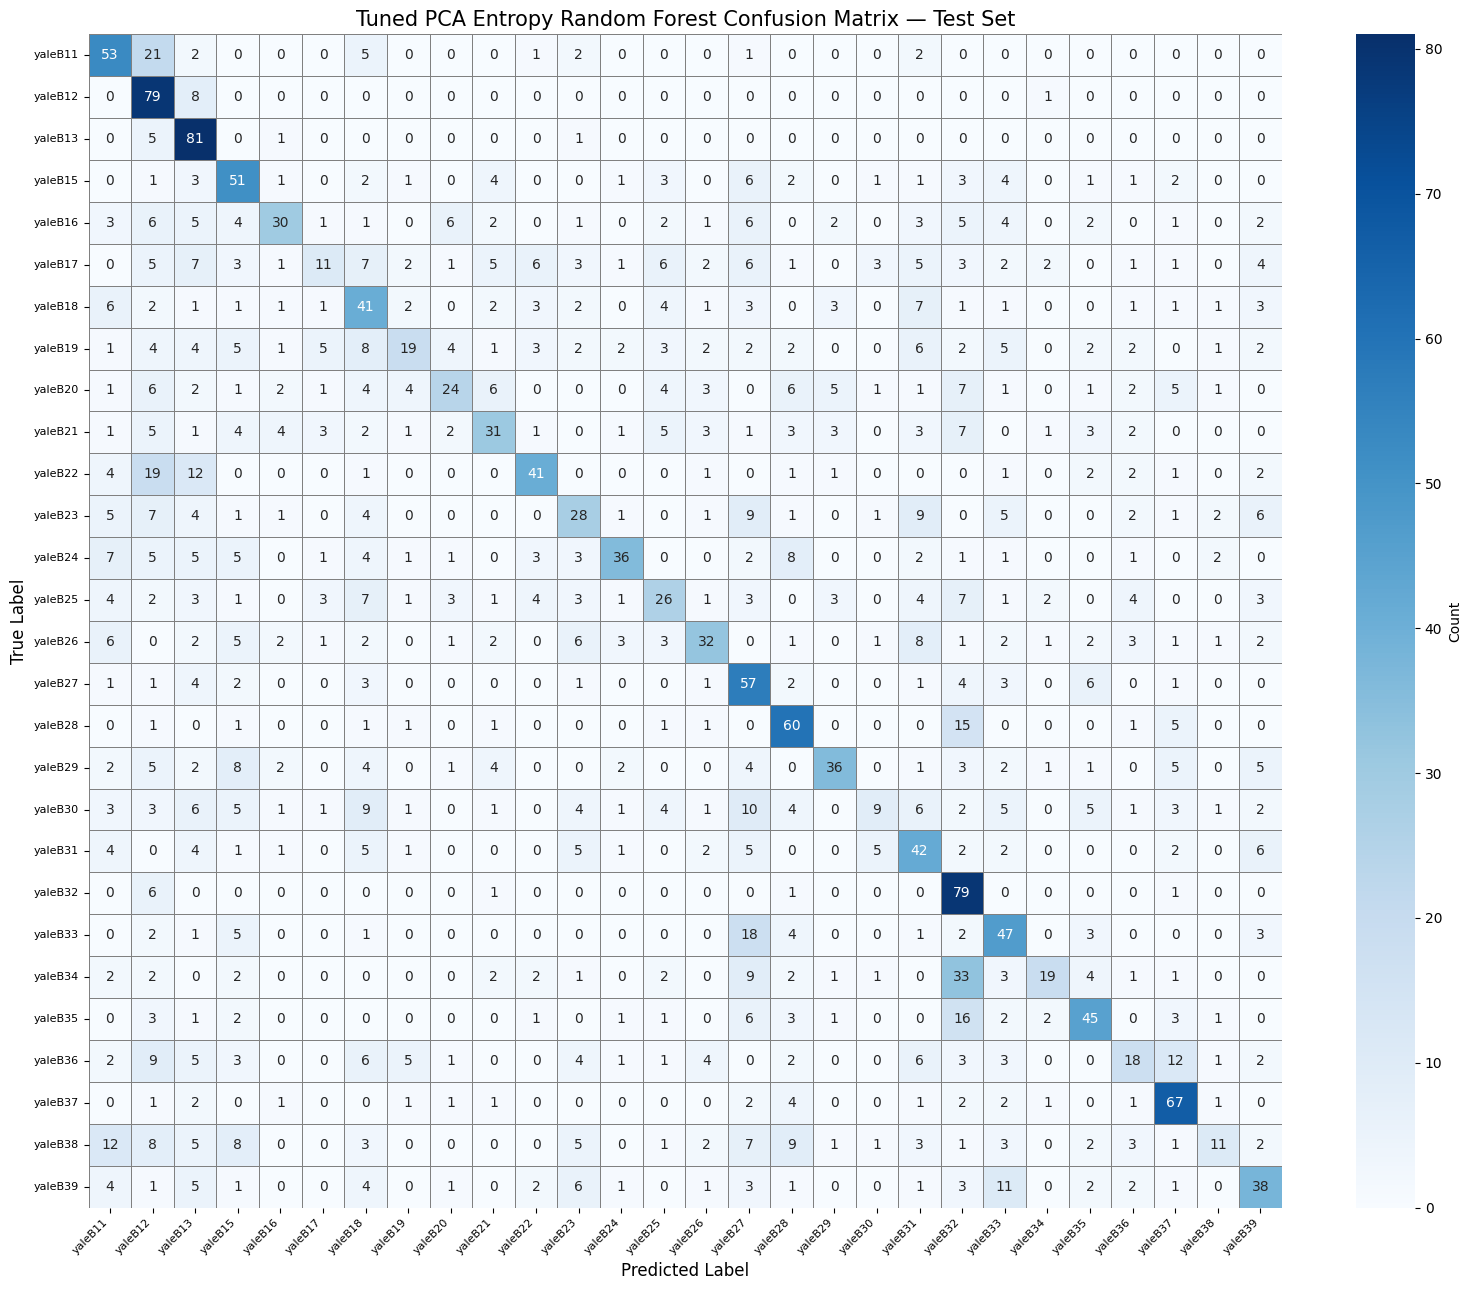

In [ ]:
# ── Cell: Confusion Matrix for Tuned PCA Entropy Random Forest ──────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

rf_pca_entropy_tuned_cm = confusion_matrix(y_test, rf_pca_entropy_tuned_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_pca_entropy_tuned_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("Tuned PCA Entropy Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_pca_entropy_tuned_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Random Forest with PCA (99% Variance) for Dimensionality Reduction

In [ ]:
# ── Cell: Apply PCA (99% Variance) ────────────────────────────────────────
from sklearn.decomposition import PCA

# We'll use the same pca_full fitted earlier to determine n_components for 99% variance
# If pca_full is not defined, refit it (e.g., if kernel was reset)
if 'pca_full' not in globals():
    pca_full = PCA().fit(X_train_scaled)

# Based on the plot, choose a number of components, e.g., to retain 99% variance
n_components_99 = np.where(np.cumsum(pca_full.explained_variance_ratio_) >= 0.99)[0][0] + 1
print(f"Number of components to retain 99% variance: {n_components_99}")

pca_99 = PCA(n_components=n_components_99, random_state=42)

X_train_pca_99 = pca_99.fit_transform(X_train_scaled)
X_val_pca_99   = pca_99.transform(X_val_scaled)
X_test_pca_99  = pca_99.transform(X_test_scaled)

print(f"Original X_train shape: {X_train_scaled.shape}")
print(f"PCA (99%) transformed X_train shape: {X_train_pca_99.shape}")

Number of components to retain 99% variance: 2169
Original X_train shape: (11466, 16384)
PCA (99%) transformed X_train shape: (11466, 2169)


### Train Random Forest on PCA (99% Variance) Data (Gini)

In [ ]:
# ── Cell: Train Random Forest Classifier with PCA (99%) Data ────────────────
print("Training Random Forest Classifier on PCA (99%) transformed data (Gini)...")
rf_pca_99_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_pca_99_model.fit(X_train_pca_99, y_train)

print("PCA (99%) Random Forest (Gini) training complete.")
print(f"PCA (99%) Random Forest (Gini) OOB score: {rf_pca_99_model.oob_score_:.4f}")

Training Random Forest Classifier on PCA (99%) transformed data (Gini)...
PCA (99%) Random Forest (Gini) training complete.
PCA (99%) Random Forest (Gini) OOB score: 0.1695


In [ ]:
# ── Cell: Evaluate PCA (99%) Random Forest Model (Gini) ───────────────────
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_pca_99_y_pred = rf_pca_99_model.predict(X_test_pca_99)

print("PCA (99%) Random Forest (Gini) Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pca_99_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pca_99_y_pred, target_names=classes))

PCA (99%) Random Forest (Gini) Test Set Evaluation:
Test Accuracy: 0.2975

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.27      0.49      0.35        87
     yaleB12       0.37      0.90      0.52        88
     yaleB13       0.41      0.90      0.56        88
     yaleB15       0.31      0.47      0.37        88
     yaleB16       0.19      0.15      0.17        87
     yaleB17       0.15      0.12      0.13        88
     yaleB18       0.21      0.24      0.22        88
     yaleB19       0.26      0.23      0.24        88
     yaleB20       0.26      0.24      0.25        88
     yaleB21       0.25      0.20      0.22        87
     yaleB22       0.35      0.22      0.27        88
     yaleB23       0.21      0.16      0.18        88
     yaleB24       0.25      0.12      0.17        88
     yaleB25       0.18      0.13      0.15        87
     yaleB26       0.15      0.14      0.14        88
     yaleB27       0.38      0.45    

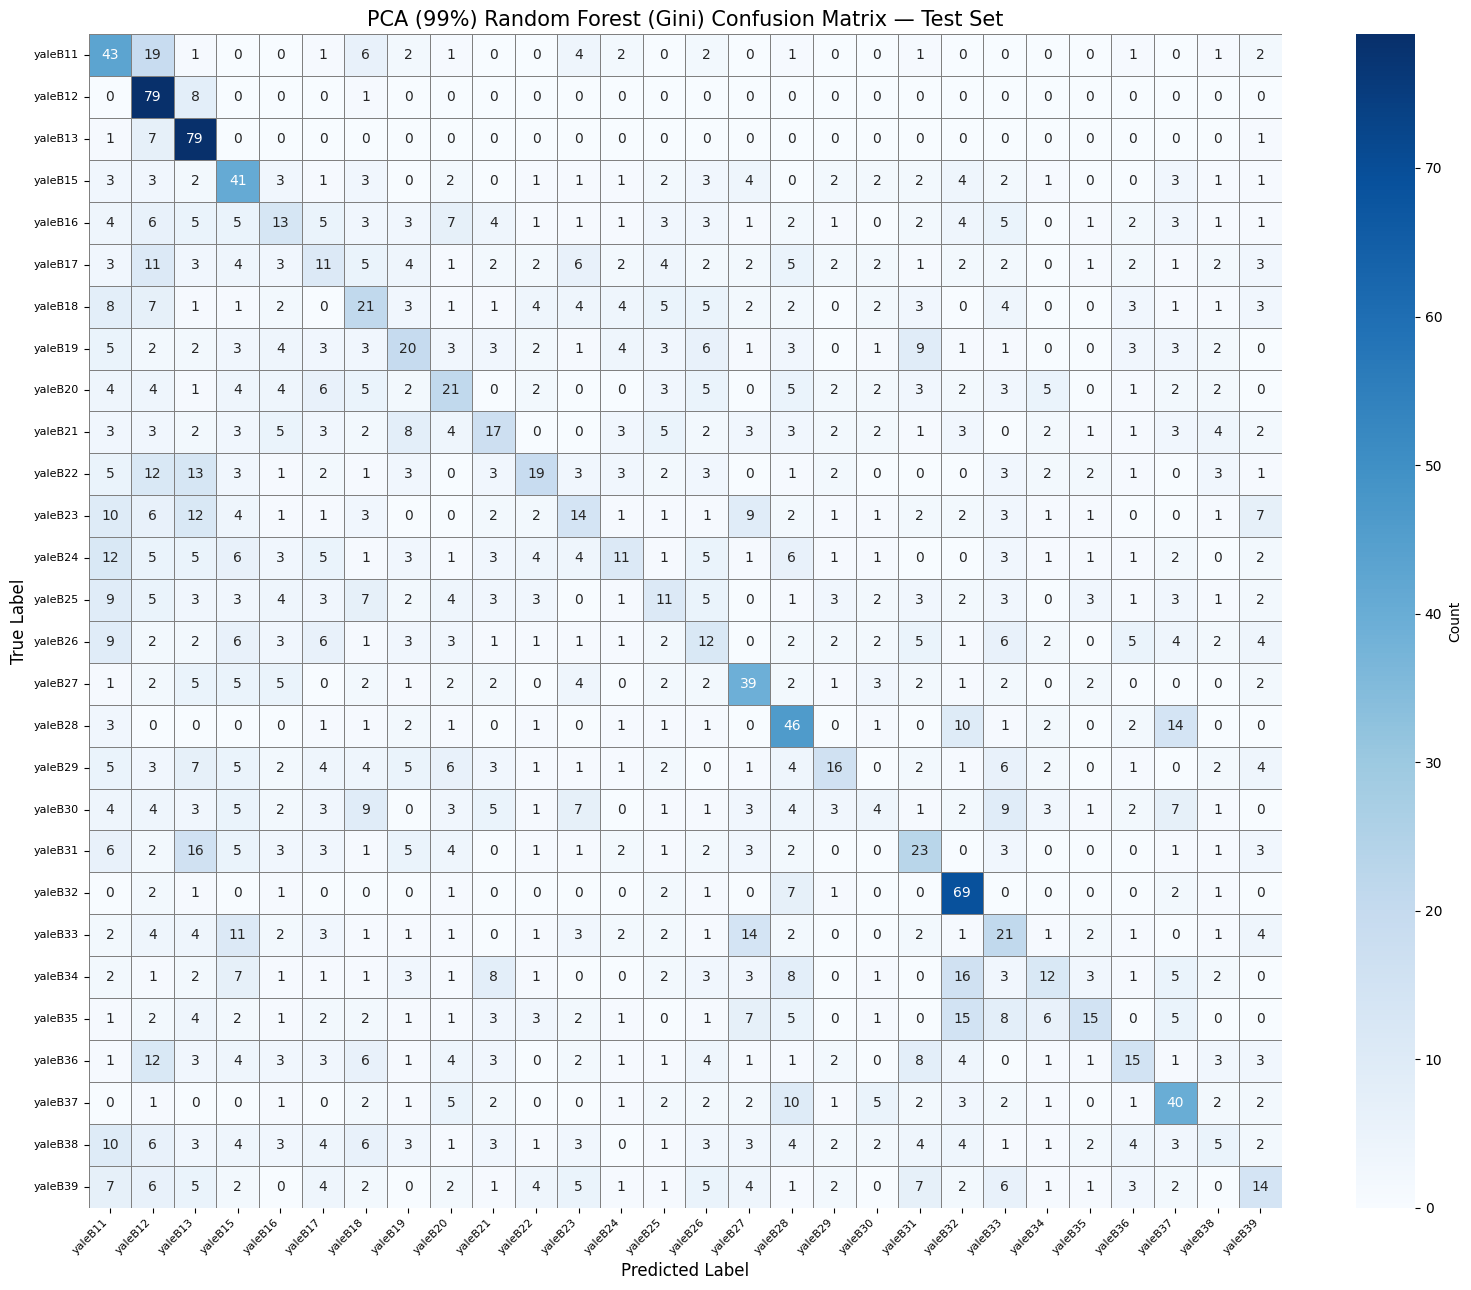

In [ ]:
# ── Cell: Confusion Matrix for PCA (99%) Random Forest (Gini) ────────────
import matplotlib.pyplot as plt
import seaborn as sns

rf_pca_99_cm = confusion_matrix(y_test, rf_pca_99_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_pca_99_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("PCA (99%) Random Forest (Gini) Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_pca_99_gini_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Train Random Forest on PCA (99% Variance) Data (Entropy)

In [ ]:
# ── Cell: Train Random Forest Classifier with PCA (99%) Data and Entropy ────
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier on PCA (99%) transformed data with Entropy...")
rf_pca_99_entropy_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True, criterion='entropy')
rf_pca_99_entropy_model.fit(X_train_pca_99, y_train)

print("PCA (99%) Entropy Random Forest training complete.")
print(f"PCA (99%) Entropy Random Forest OOB score: {rf_pca_99_entropy_model.oob_score_:.4f}")

Training Random Forest Classifier on PCA (99%) transformed data with Entropy...
PCA (99%) Entropy Random Forest training complete.
PCA (99%) Entropy Random Forest OOB score: 0.1305


In [ ]:
# ── Cell: Evaluate PCA (99%) Entropy Random Forest Model ──────────────────
from sklearn.metrics import accuracy_score, classification_report

rf_pca_99_entropy_y_pred = rf_pca_99_entropy_model.predict(X_test_pca_99)

print("PCA (99%) Entropy Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pca_99_entropy_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pca_99_entropy_y_pred, target_names=classes))

PCA (99%) Entropy Random Forest Test Set Evaluation:
Test Accuracy: 0.2251

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.17      0.30      0.22        87
     yaleB12       0.36      0.75      0.49        88
     yaleB13       0.39      0.70      0.51        88
     yaleB15       0.14      0.22      0.17        88
     yaleB16       0.13      0.11      0.12        87
     yaleB17       0.16      0.15      0.15        88
     yaleB18       0.09      0.11      0.10        88
     yaleB19       0.13      0.15      0.14        88
     yaleB20       0.20      0.22      0.21        88
     yaleB21       0.18      0.14      0.15        87
     yaleB22       0.25      0.19      0.22        88
     yaleB23       0.14      0.12      0.13        88
     yaleB24       0.21      0.19      0.20        88
     yaleB25       0.13      0.09      0.11        87
     yaleB26       0.07      0.06      0.06        88
     yaleB27       0.18      0.21   

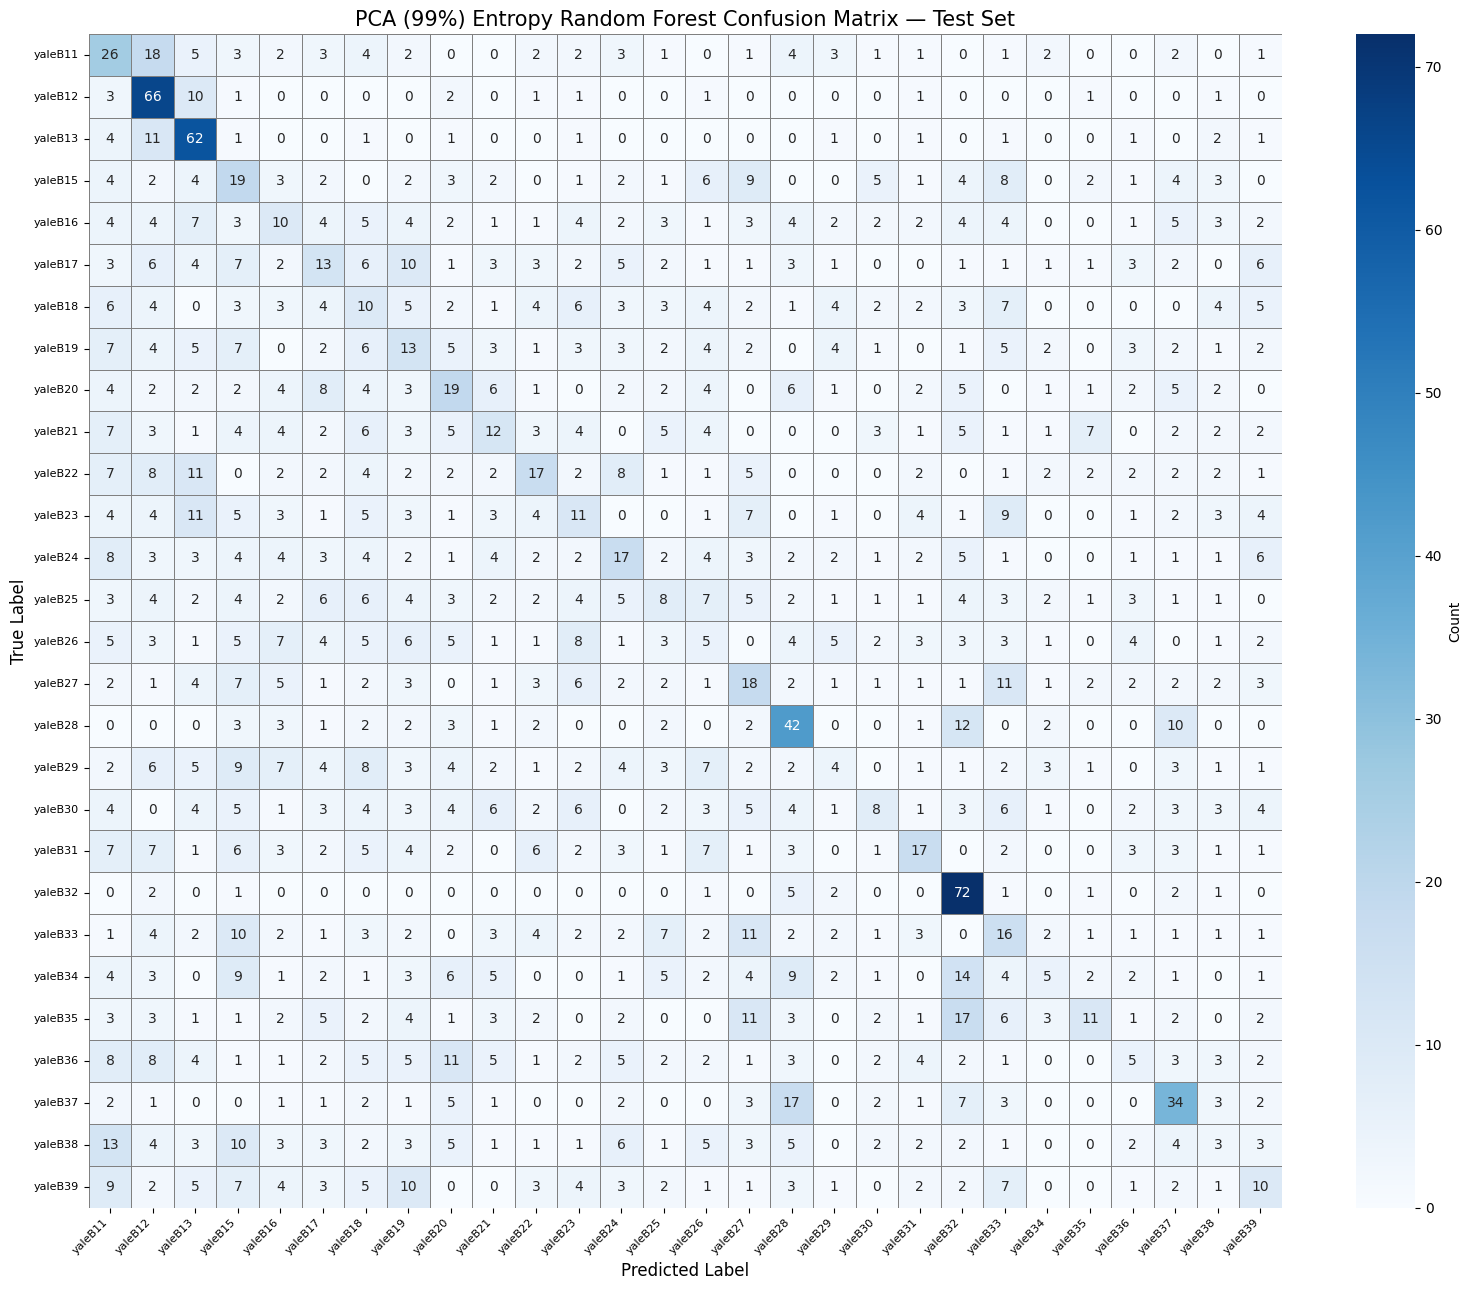

In [ ]:
# ── Cell: Confusion Matrix for PCA (99%) Entropy Random Forest ──────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

rf_pca_99_entropy_cm = confusion_matrix(y_test, rf_pca_99_entropy_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_pca_99_entropy_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("PCA (99%) Entropy Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_pca_99_entropy_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Hyperparameter Tuning for Random Forest with PCA (99% Variance) and Entropy

In [35]:
# ── Cell: Hyperparameter Tuning with RandomizedSearchCV for PCA (99%) Entropy ────
from sklearn.model_selection import RandomizedSearchCV, ParameterSampler
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats
import time

# Parameter space (using same as previous tuning for consistency)
param_dist_pca_99_entropy = {
    'n_estimators': stats.randint(50, 200),
    'max_features': ['sqrt', 'log2'],
    'max_depth': stats.randint(5, 30),
    'min_samples_split': stats.randint(2, 10),
    'min_samples_leaf': stats.randint(1, 5),
    'bootstrap': [True],
    'criterion': ['entropy'] # Explicitly set criterion to entropy
}

# Model
rf_pca_99_entropy_tune_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Randomized Search (using the custom VerboseRandomSearch class if it's defined, otherwise default)
# Assuming VerboseRandomSearch is already defined in the notebook (cell 7006d24a)

# Check if VerboseRandomSearch class is available, if not, define a dummy for execution
if 'VerboseRandomSearch' not in globals():
    class VerboseRandomSearch(RandomizedSearchCV):
        def _run_search(self, evaluate_candidates):
            param_list = list(ParameterSampler(
                self.param_distributions,
                self.n_iter,
                random_state=self.random_state
            ))
            total_start = time.time()
            for i, params in enumerate(param_list):
                print(f"\n🔹 Iteration {i+1}/{self.n_iter}")
                print(f"Params: {params}")
                start = time.time()
                evaluate_candidates([params])
                end = time.time()
                print(f"✅ Done in {end - start:.2f} sec")
            total_end = time.time()
            print(f"\n🔥 Total Time: {(total_end - total_start)/60:.2f} minutes")

random_search_pca_99_entropy = VerboseRandomSearch(
    estimator=rf_pca_99_entropy_tune_model,
    param_distributions=param_dist_pca_99_entropy,
    n_iter=30,   # balanced (fast + effective)
    cv=2,        # faster
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("🚀 Starting Randomized Search for PCA (99%) Entropy Random Forest...\n")

random_search_pca_99_entropy.fit(X_train_pca_99, y_train)

print("\n🎯 Best Parameters:", random_search_pca_99_entropy.best_params_)
print(f"🏆 Best CV Score: {random_search_pca_99_entropy.best_score_:.4f}")

🚀 Starting Randomized Search for PCA (99%) Entropy Random Forest...


🔹 Iteration 1/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 11, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 156}
✅ Done in 101.21 sec

🔹 Iteration 2/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 171}
✅ Done in 437.77 sec

🔹 Iteration 3/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 23, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 137}
✅ Done in 366.40 sec

🔹 Iteration 4/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 180}
✅ Done in 129.63 sec

🔹 Iteration 5/30
Params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_leaf': 

### Evaluate Tuned Random Forest with PCA (99% Variance) and Entropy

In [36]:
# ── Cell: Evaluate Tuned PCA (99%) Entropy Random Forest Model ────────────────
from sklearn.metrics import accuracy_score, classification_report

rf_pca_99_entropy_best_model = random_search_pca_99_entropy.best_estimator_

rf_pca_99_entropy_tuned_y_pred = rf_pca_99_entropy_best_model.predict(X_test_pca_99)

print("Tuned PCA (99%) Entropy Random Forest Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pca_99_entropy_tuned_y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pca_99_entropy_tuned_y_pred, target_names=classes))

Tuned PCA (99%) Entropy Random Forest Test Set Evaluation:
Test Accuracy: 0.3118

Classification Report:
              precision    recall  f1-score   support

     yaleB11       0.24      0.39      0.30        87
     yaleB12       0.27      0.88      0.41        88
     yaleB13       0.24      0.93      0.38        88
     yaleB15       0.28      0.45      0.35        88
     yaleB16       0.50      0.13      0.20        87
     yaleB17       0.00      0.00      0.00        88
     yaleB18       0.45      0.34      0.39        88
     yaleB19       0.32      0.08      0.13        88
     yaleB20       1.00      0.12      0.22        88
     yaleB21       0.45      0.11      0.18        87
     yaleB22       0.36      0.24      0.29        88
     yaleB23       0.26      0.25      0.25        88
     yaleB24       0.55      0.20      0.30        88
     yaleB25       0.40      0.11      0.18        87
     yaleB26       0.35      0.20      0.26        88
     yaleB27       0.29      0

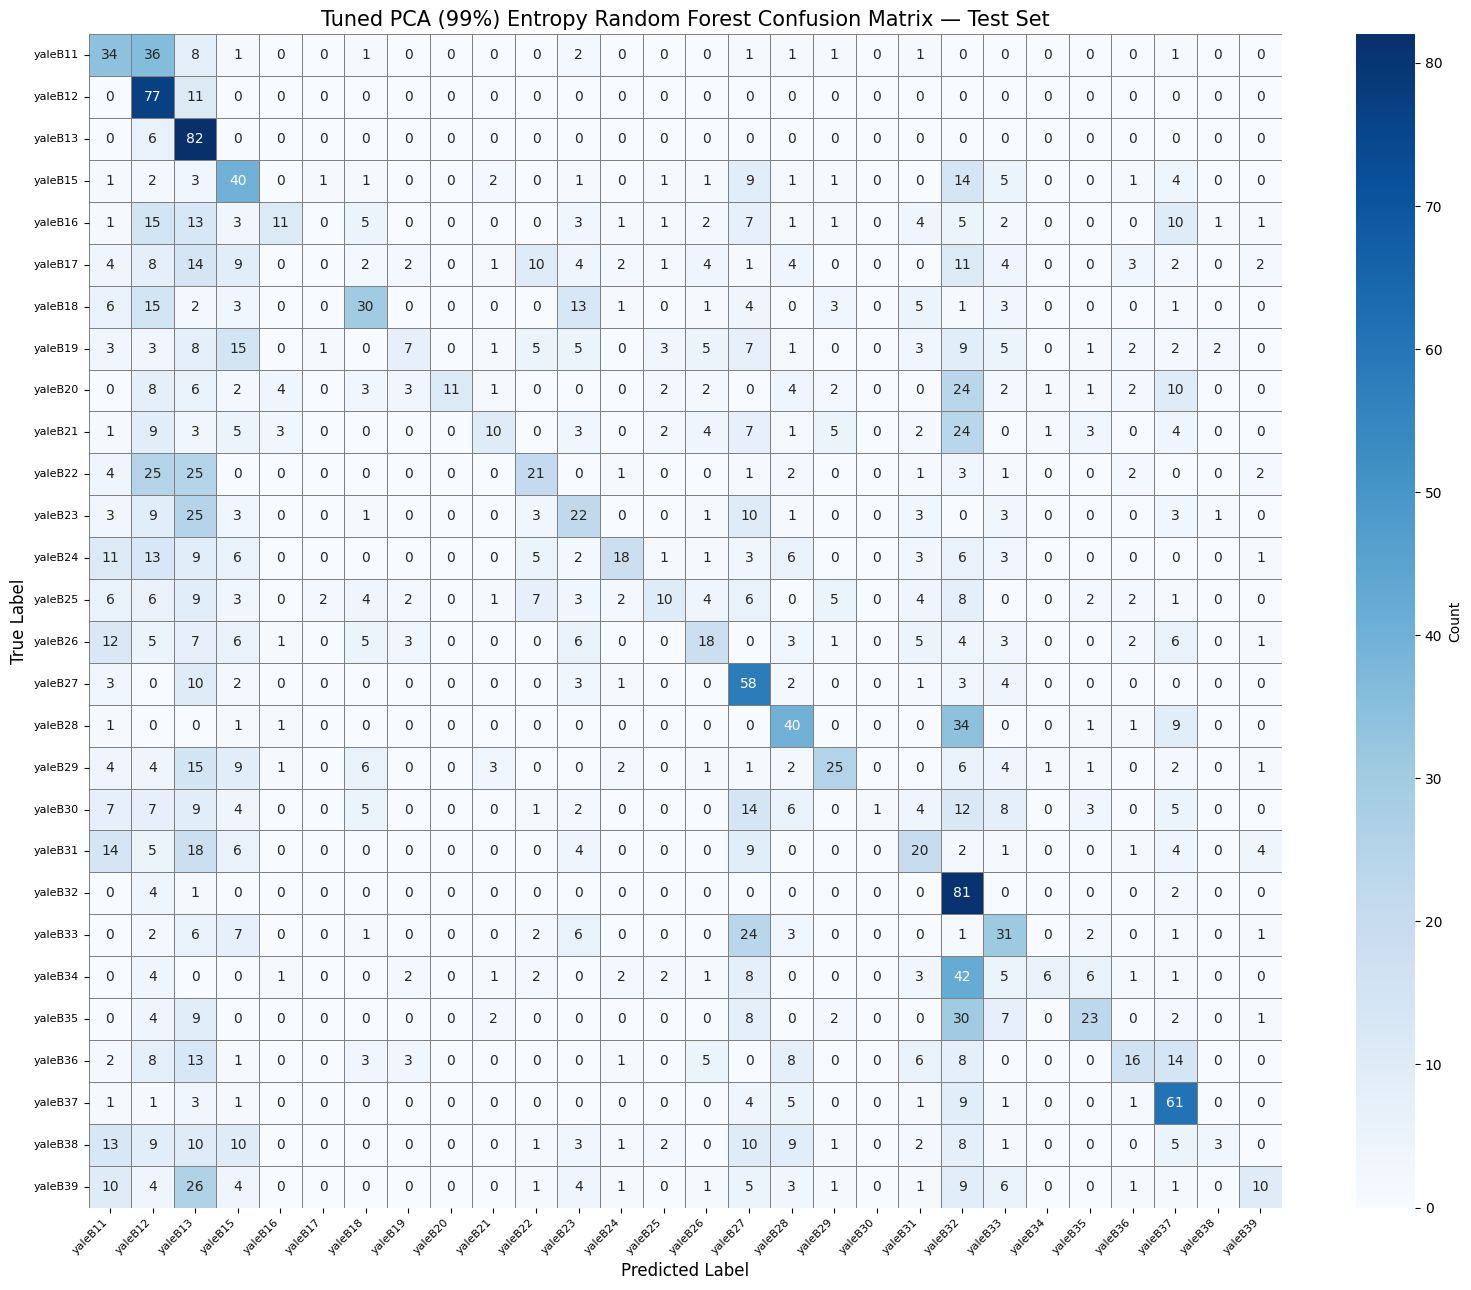

In [37]:
# ── Cell: Confusion Matrix for Tuned PCA (99%) Entropy Random Forest ──────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

rf_pca_99_entropy_tuned_cm = confusion_matrix(y_test, rf_pca_99_entropy_tuned_y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(rf_pca_99_entropy_tuned_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("Tuned PCA (99%) Entropy Random Forest Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12); plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("rf_pca_99_entropy_tuned_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### PCA (99% Variance) Random Forest Performance Summary

This section concludes the implementation and evaluation of the Random Forest model with PCA retaining 99% variance. You can now compare the test accuracy, classification report, and confusion matrix of these models with previous implementations to thoroughly assess the impact of different PCA variance thresholds and criterion on performance.

### PCA Entropy Random Forest Performance Summary

This section provides the performance summary for the Random Forest model with PCA using the Entropy criterion, both before and after hyperparameter tuning. You can now compare these results with the previous Random Forest implementations and the CNN model to get a comprehensive understanding of their effectiveness on this dataset.

### PCA Random Forest Performance Summary

This section concludes the implementation and evaluation of the Random Forest model with PCA. You can now compare the test accuracy, classification report, and confusion matrix of this model with the previous Random Forest implementations (Gini and Entropy) and the CNN model to determine if dimensionality reduction via PCA offered any performance advantages or trade-offs for this specific dataset and model.